# Install Packages & Upload Dataset

In [2]:
# ============================================
# CELL 1: SETUP FOR GOOGLE COLAB
# ============================================

# Install required packages
!pip install xgboost shap -q

# Upload dataset
from google.colab import files
print("📁 Please upload smartcare_ai_dataset_1000.csv")
uploaded = files.upload()

# Get the uploaded filename
file_name = list(uploaded.keys())[0]
print(f"✅ Uploaded: {file_name}")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
RANDOM_STATE = 42

# Load the dataset (use the uploaded filename)
df_raw = pd.read_csv(file_name)
print(f"✅ Dataset loaded: {df_raw.shape}")

# Load data dictionary if uploaded
try:
    data_dict = pd.read_csv('smartcare_ai_dataset_data_dictionary.csv')
    print("✅ Data dictionary loaded")
except:
    print("⚠️ Data dictionary not found - continuing without it")

📁 Please upload smartcare_ai_dataset_1000.csv


Saving smartcare_ai_dataset_1000.csv to smartcare_ai_dataset_1000.csv
Saving smartcare_ai_dataset_data_dictionary.csv to smartcare_ai_dataset_data_dictionary.csv
✅ Uploaded: smartcare_ai_dataset_1000.csv
✅ Dataset loaded: (1000, 33)
✅ Data dictionary loaded


# Dataset Understanding

In [3]:
# ============================================
# CELL 2: TASK 02 - DATASET UNDERSTANDING
# ============================================

# 1. View first 5 rows
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
df_raw.head()

# 2. Dataset info
print("\nShape:", df_raw.shape)
df_raw.info()

# 3. Missing values
print("\nMissing values per column:")
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])

print("\nDuplicate rows:", df_raw.duplicated().sum())

# 4. Check missing room_type by admitted status
print("\nroom_type missing by admitted:")
print(df_raw.groupby('admitted')['room_type'].apply(lambda x: x.isnull().sum()))

# 5. Target distribution
print("\nTarget (no_show) distribution:")
print(df_raw['no_show'].value_counts())
print(df_raw['no_show'].value_counts(normalize=True).round(3))

# 6. Target leakage check
print("\nTARGET LEAKAGE CHECK:")
print(pd.crosstab(df_raw['appointment_status'], df_raw['no_show']))

# 7. Statistical summary
print("\nStatistical Summary:")
print(df_raw.describe().T)

DATASET OVERVIEW

Shape: (1000, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   record_id                     1000 non-null   int64  
 1   patient_id                    1000 non-null   object 
 2   age                           1000 non-null   int64  
 3   gender                        1000 non-null   object 
 4   blood_group                   1000 non-null   object 
 5   department                    1000 non-null   object 
 6   diagnosis                     1000 non-null   object 
 7   appointment_date              1000 non-null   object 
 8   waiting_days                  1000 non-null   int64  
 9   previous_appointments         1000 non-null   int64  
 10  missed_previous_appointments  1000 non-null   int64  
 11  appointment_status            1000 non-null   object 
 12  admitted                   

# Data Preprocessing

In [4]:
# ============================================
# CELL 3: TASK 03 - DATA PREPROCESSING
# ============================================

from sklearn.preprocessing import StandardScaler

print("=" * 50)
print("DATA PREPROCESSING")
print("=" * 50)

# Copy dataset
df = df_raw.copy()

# 1. Remove leakage columns
LEAK_COLS = ['appointment_status', 'readmitted_30_days', 'disease_risk_level']
df = df.drop(columns=LEAK_COLS)
print(f"✅ Removed leakage columns: {LEAK_COLS}")

# 2. Engineeer date features then drop appointment_date
df['appointment_month'] = pd.to_datetime(df['appointment_date']).dt.month
df['appointment_dayofweek'] = pd.to_datetime(df['appointment_date']).dt.dayofweek
df['is_weekend_appt'] = df['appointment_dayofweek'].isin([5, 6]).astype(int)
ID_COLS = ['record_id', 'patient_id', 'appointment_date']
df = df.drop(columns=ID_COLS)
print(f"✅ Removed identifier columns")

# 3. Handle missing values
df['room_type'] = df['room_type'].fillna('Not Admitted')
print(f"✅ Filled missing room_type values")

# 4. Remove duplicates
n_dupes = df.duplicated().sum()
df = df.drop_duplicates()
print(f"✅ Removed {n_dupes} duplicate rows")

# 5. Feature engineering
df['missed_ratio'] = df['missed_previous_appointments'] / df['previous_appointments'].replace(0, np.nan)
df['missed_ratio'] = df['missed_ratio'].fillna(0)
df['is_first_visit'] = (df['previous_appointments'] == 0).astype(int)
median_wait = df['waiting_days'].median()
df['long_wait_flag'] = (df['waiting_days'] > median_wait).astype(int)
df['age_group'] = pd.cut(df['age'], bins=[0, 18, 35, 50, 65, 100],
                          labels=['0-18', '19-35', '36-50', '51-65', '65+'])
print(f"✅ Created engineered features")

# 6. Remove post-visit columns
POST_VISIT_COLS = ['room_charge_lkr', 'length_of_stay_days', 'admitted', 'room_type',
                    'lab_tests_count', 'treatments_count', 'lab_charge_lkr',
                    'medicine_charge_lkr', 'total_bill_lkr', 'payment_status',
                    'systolic_bp', 'diastolic_bp', 'blood_sugar_mg_dl',
                    'cholesterol_mg_dl', 'bmi']
df = df.drop(columns=POST_VISIT_COLS)
print(f"✅ Removed post-visit columns")

print("\nShape after feature engineering:", df.shape)
print("Final columns:", list(df.columns))

# 7. Encoding
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})
nominal_cols = ['blood_group', 'department', 'diagnosis', 'payment_method', 'age_group']
df_encoded = pd.get_dummies(df, columns=nominal_cols, drop_first=True)
print(f"✅ One-hot encoded: {nominal_cols}")

# 8. Split features and target
target = 'no_show'
X = df_encoded.drop(columns=[target])
y = df_encoded[target]

# 9. Scaling
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numeric_cols] = scaler.fit_transform(X[numeric_cols])

print(f"\nFinal feature count: {X.shape[1]}")
print("Target distribution:")
print(y.value_counts(normalize=True))

# 10. Feature correlation check
corr_with_target = X.select_dtypes(include=['int64','float64','bool']).astype(float).apply(lambda c: c.corr(y.astype(float)))
print("\nTop correlated features with no_show:")
print(corr_with_target.abs().sort_values(ascending=False).head(15))

# Save processed data (optional - for later use)
X.to_csv('X_processed.csv', index=False)
X_scaled.to_csv('X_scaled.csv', index=False)
y.to_csv('y.csv', index=False)
df.to_csv('df_engineered.csv', index=False)
print("\n✅ Saved processed datasets")

DATA PREPROCESSING
✅ Removed leakage columns: ['appointment_status', 'readmitted_30_days', 'disease_risk_level']
✅ Removed identifier columns
✅ Filled missing room_type values
✅ Removed 0 duplicate rows
✅ Created engineered features
✅ Removed post-visit columns

Shape after feature engineering: (1000, 19)
Final columns: ['age', 'gender', 'blood_group', 'department', 'diagnosis', 'waiting_days', 'previous_appointments', 'missed_previous_appointments', 'previous_admissions', 'consultation_fee_lkr', 'payment_method', 'no_show', 'appointment_month', 'appointment_dayofweek', 'is_weekend_appt', 'missed_ratio', 'is_first_visit', 'long_wait_flag', 'age_group']
✅ One-hot encoded: ['blood_group', 'department', 'diagnosis', 'payment_method', 'age_group']

Final feature count: 42
Target distribution:
no_show
0    0.505
1    0.495
Name: proportion, dtype: float64

Top correlated features with no_show:
waiting_days                    0.242564
long_wait_flag                  0.227792
missed_ratio    

# Exploratory Data Analysis

EXPLORATORY DATA ANALYSIS


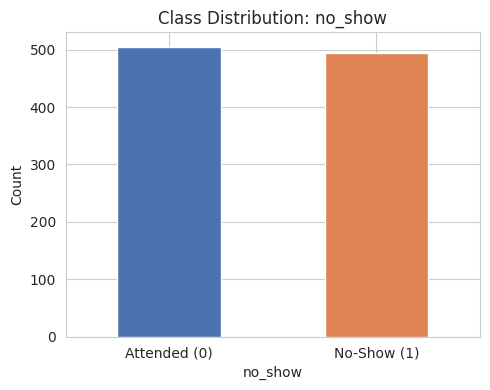

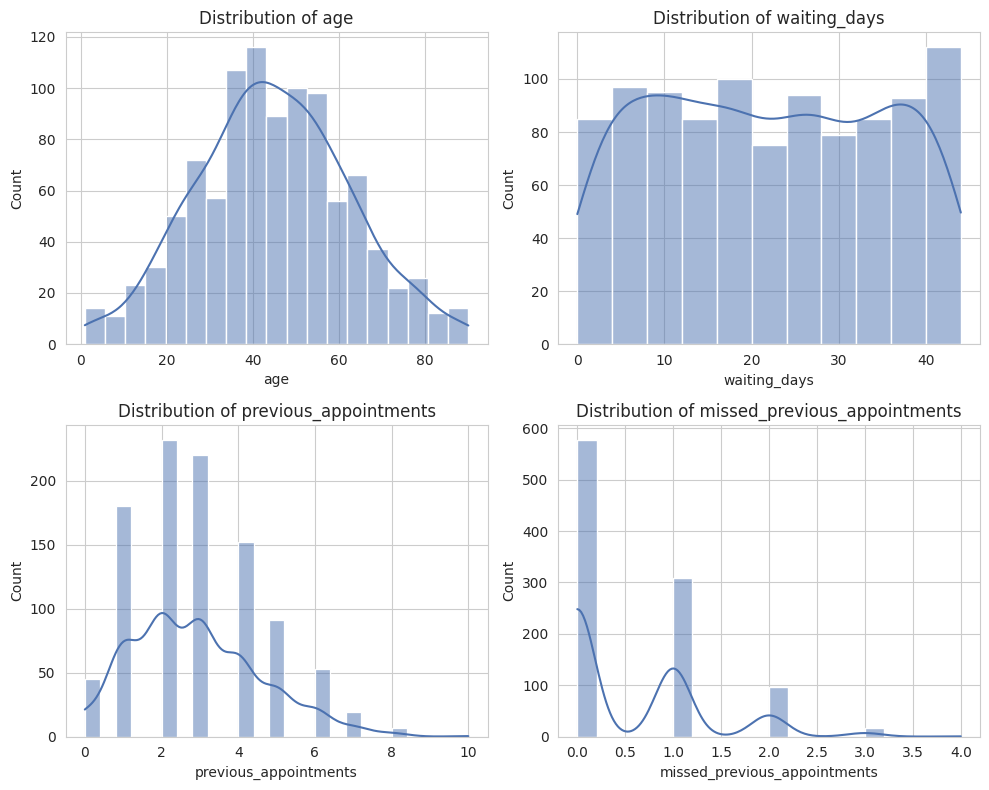

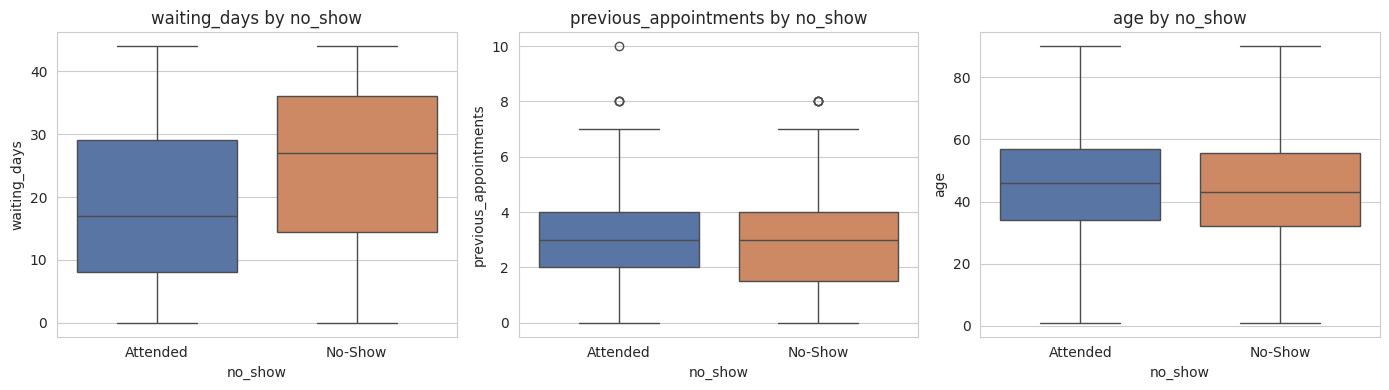

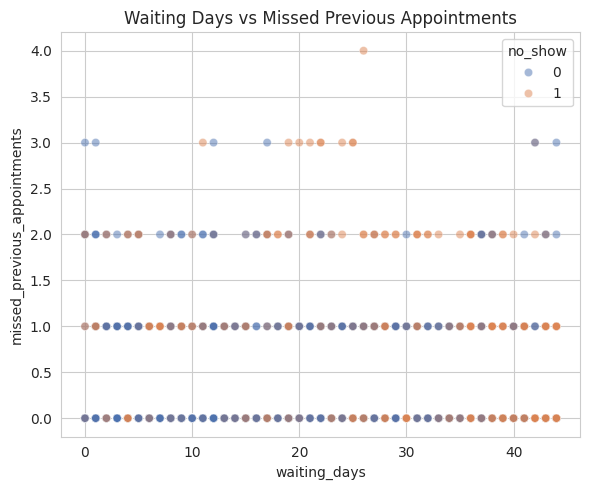

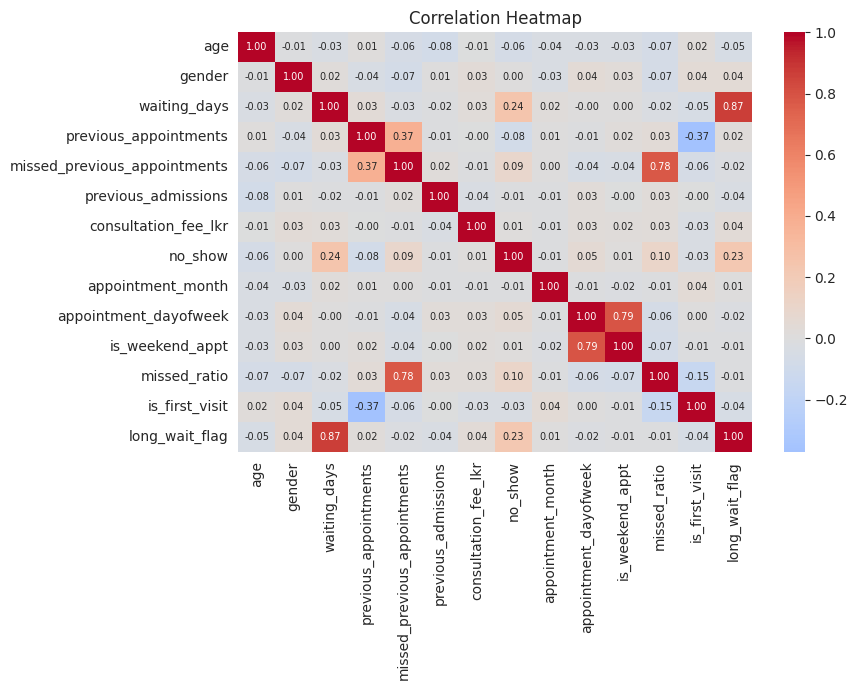

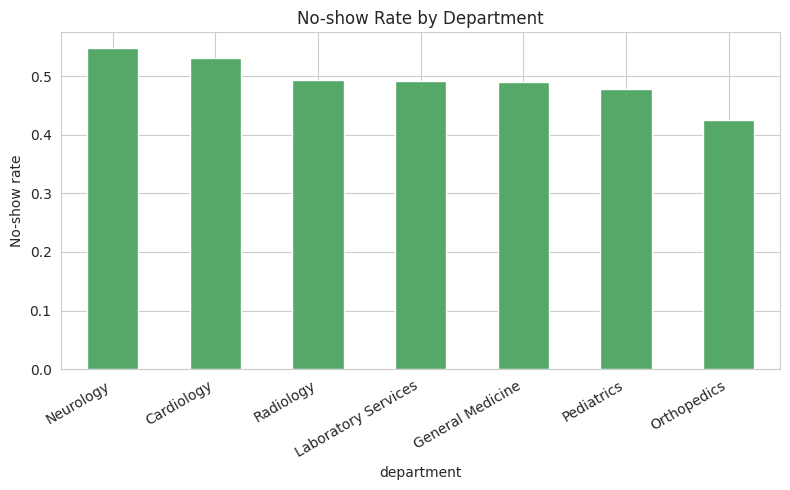

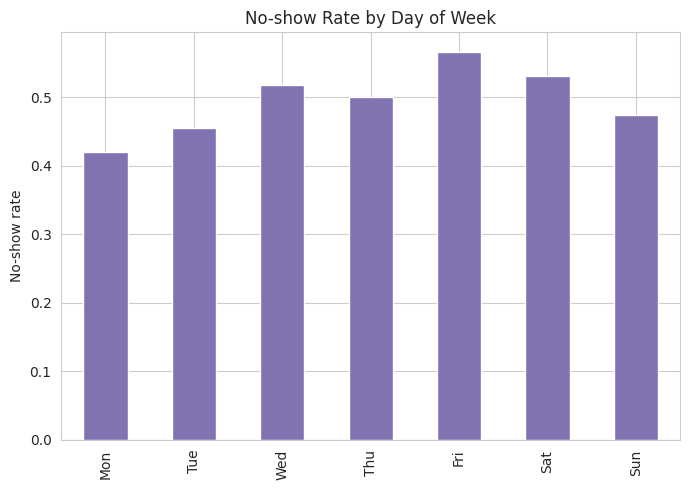


✅ All 7 visualizations created!

KEY EDA INSIGHTS

1. Overall no-show rate: 49.5%

2. Long wait (>22 days) no-show rate: 61.4%
   Short wait (<=22 days) no-show rate: 38.6%

3. Missed ratio correlation: 0.104

4. Department with highest no-show: Neurology
5. Department with lowest no-show: Orthopedics


In [5]:
# ============================================
# CELL 4: TASK 04 - EXPLORATORY DATA ANALYSIS
# ============================================

print("=" * 50)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 50)

# Use engineered df
df = pd.read_csv('df_engineered.csv')

# 1. Class Distribution
plt.figure(figsize=(5,4))
df['no_show'].value_counts().sort_index().plot(kind='bar', color=['#4C72B0','#DD8452'])
plt.title('Class Distribution: no_show')
plt.xticks([0,1], ['Attended (0)', 'No-Show (1)'], rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('01_class_distribution.png')
plt.show()

# 2. Histograms
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
num_cols = ['age', 'waiting_days', 'previous_appointments', 'missed_previous_appointments']
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='#4C72B0')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.savefig('02_histograms.png')
plt.show()

# 3. Boxplots
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['waiting_days', 'previous_appointments', 'age']):
    sns.boxplot(data=df, x='no_show', y=col, ax=ax, palette=['#4C72B0','#DD8452'])
    ax.set_xticklabels(['Attended', 'No-Show'])
    ax.set_title(f'{col} by no_show')
plt.tight_layout()
plt.savefig('03_boxplots.png')
plt.show()

# 4. Scatterplot
plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x='waiting_days', y='missed_previous_appointments',
                hue='no_show', alpha=0.5, palette=['#4C72B0','#DD8452'])
plt.title('Waiting Days vs Missed Previous Appointments')
plt.tight_layout()
plt.savefig('04_scatter.png')
plt.show()

# 5. Correlation Heatmap
plt.figure(figsize=(9,7))
sns.heatmap(df.select_dtypes(include=['int64','float64']).corr(),
            annot=True, fmt='.2f', cmap='coolwarm', center=0, annot_kws={"size":7})
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('05_correlation_heatmap.png')
plt.show()

# 6. No-show by department
plt.figure(figsize=(8,5))
rate = df.groupby('department')['no_show'].mean().sort_values(ascending=False)
rate.plot(kind='bar', color='#55A868')
plt.ylabel('No-show rate')
plt.title('No-show Rate by Department')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('06_noshow_by_department.png')
plt.show()

# 7. No-show by day of week
plt.figure(figsize=(7,5))
dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
rate_dow = df.groupby('appointment_dayofweek')['no_show'].mean()
rate_dow.index = [dow_labels[i] for i in rate_dow.index]
rate_dow.plot(kind='bar', color='#8172B2')
plt.ylabel('No-show rate')
plt.title('No-show Rate by Day of Week')
plt.tight_layout()
plt.savefig('07_noshow_by_dayofweek.png')
plt.show()

print("\n✅ All 7 visualizations created!")

# Print key insights
print("\n" + "=" * 50)
print("KEY EDA INSIGHTS")
print("=" * 50)
print(f"\n1. Overall no-show rate: {df['no_show'].mean()*100:.1f}%")
print(f"\n2. Long wait (>22 days) no-show rate: {df[df['long_wait_flag']==1]['no_show'].mean()*100:.1f}%")
print(f"   Short wait (<=22 days) no-show rate: {df[df['long_wait_flag']==0]['no_show'].mean()*100:.1f}%")
print(f"\n3. Missed ratio correlation: {df['missed_ratio'].corr(df['no_show']):.3f}")
print(f"\n4. Department with highest no-show: {df.groupby('department')['no_show'].mean().idxmax()}")
print(f"5. Department with lowest no-show: {df.groupby('department')['no_show'].mean().idxmin()}")

# Model Development & Evaluation

MODEL DEVELOPMENT & EVALUATION
Train shape: (800, 42), Test shape: (200, 42)
Train target balance:
no_show
0    0.505
1    0.495
Name: proportion, dtype: float64

Training 7 models...

--- Logistic Regression ---
  accuracy: 0.6000
  precision: 0.5960
  recall: 0.5960
  f1: 0.5960
  roc_auc: 0.6243
  cv_f1_mean: 0.5801
  cv_f1_std: 0.0183

--- Decision Tree ---
  accuracy: 0.5050
  precision: 0.5000
  recall: 0.4747
  f1: 0.4870
  roc_auc: 0.5175
  cv_f1_mean: 0.5448
  cv_f1_std: 0.0385

--- Random Forest ---
  accuracy: 0.6250
  precision: 0.6395
  recall: 0.5556
  f1: 0.5946
  roc_auc: 0.6585
  cv_f1_mean: 0.5904
  cv_f1_std: 0.0214

--- Naive Bayes ---
  accuracy: 0.5600
  precision: 0.5567
  recall: 0.5455
  f1: 0.5510
  roc_auc: 0.5609
  cv_f1_mean: 0.5413
  cv_f1_std: 0.0297

--- KNN ---
  accuracy: 0.5750
  precision: 0.5673
  recall: 0.5960
  f1: 0.5813
  roc_auc: 0.5838
  cv_f1_mean: 0.5452
  cv_f1_std: 0.0241

--- SVM (RBF) ---
  accuracy: 0.6200
  precision: 0.6264
  recall:

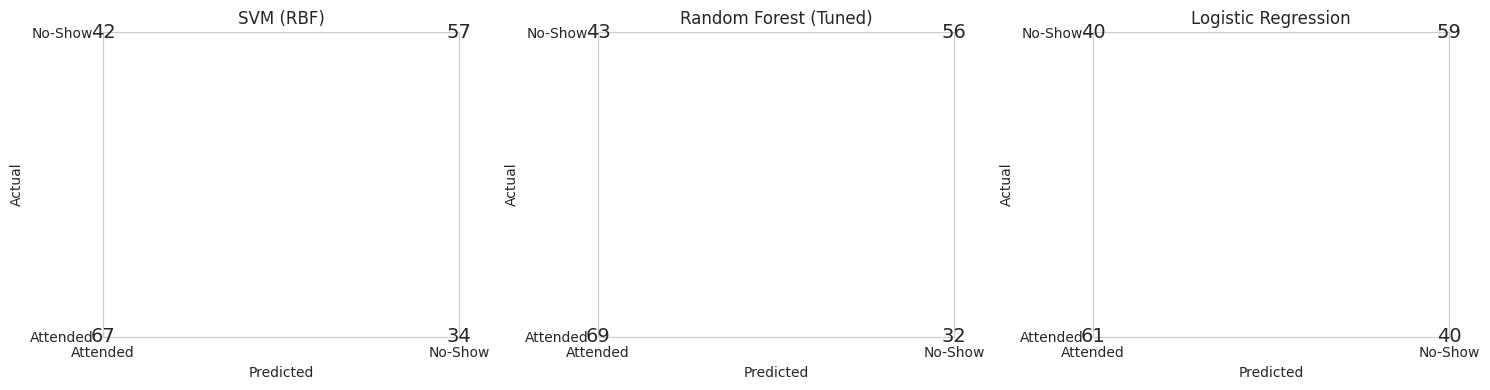

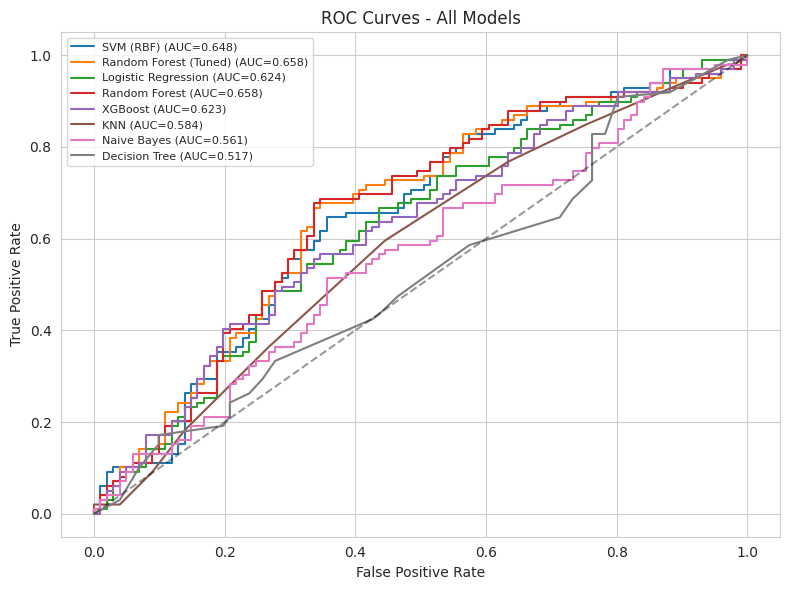


✅ Model saved as 'best_model_random_forest.pkl'


In [6]:
# ============================================
# CELL 5: TASK 05 & 06 - MODEL DEVELOPMENT & EVALUATION
# ============================================

print("=" * 50)
print("MODEL DEVELOPMENT & EVALUATION")
print("=" * 50)

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

# Load data
X = pd.read_csv('X_processed.csv')
X_scaled = pd.read_csv('X_scaled.csv')
y = pd.read_csv('y.csv').squeeze()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
Xs_train, Xs_test, _, _ = train_test_split(
    X_scaled, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train target balance:\n{y_train.value_counts(normalize=True)}")

results = {}
fitted_models = {}

def evaluate(name, model, Xtr, Xte, ytr, yte):
    model.fit(Xtr, ytr)
    y_pred = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:, 1] if hasattr(model, 'predict_proba') else None

    metrics = {
        'accuracy': accuracy_score(yte, y_pred),
        'precision': precision_score(yte, y_pred),
        'recall': recall_score(yte, y_pred),
        'f1': f1_score(yte, y_pred),
        'roc_auc': roc_auc_score(yte, y_proba) if y_proba is not None else np.nan,
    }
    cv_scores = cross_val_score(model, pd.concat([Xtr,Xte]), pd.concat([ytr,yte]), cv=5, scoring='f1')
    metrics['cv_f1_mean'] = cv_scores.mean()
    metrics['cv_f1_std'] = cv_scores.std()

    results[name] = metrics
    fitted_models[name] = model
    print(f"\n--- {name} ---")
    for k, v in metrics.items():
        print(f"  {k}: {v:.4f}")
    return y_pred, y_proba

# Train models
print("\nTraining 7 models...")

# 1. Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
evaluate('Logistic Regression', lr, Xs_train, Xs_test, y_train, y_test)

# 2. Decision Tree
dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=20, random_state=RANDOM_STATE)
evaluate('Decision Tree', dt, X_train, X_test, y_train, y_test)

# 3. Random Forest
rf = RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=10, random_state=RANDOM_STATE)
evaluate('Random Forest', rf, X_train, X_test, y_train, y_test)

# 4. Naive Bayes
nb = GaussianNB()
evaluate('Naive Bayes', nb, Xs_train, Xs_test, y_train, y_test)

# 5. KNN
knn = KNeighborsClassifier(n_neighbors=15)
evaluate('KNN', knn, Xs_train, Xs_test, y_train, y_test)

# 6. SVM
svm = SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)
evaluate('SVM (RBF)', svm, Xs_train, Xs_test, y_train, y_test)

# 7. XGBoost
xgb = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=RANDOM_STATE)
evaluate('XGBoost', xgb, X_train, X_test, y_train, y_test)

# Hyperparameter Tuning - Random Forest
print("\n" + "=" * 50)
print("HYPERPARAMETER TUNING - Random Forest")
print("=" * 50)

param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [4, 6, 8, 10],
    'min_samples_leaf': [5, 10, 20]
}
grid = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE),
                     param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

print(f"Best params: {grid.best_params_}")
print(f"Best CV F1: {grid.best_score_:.4f}")

rf_tuned = grid.best_estimator_
evaluate('Random Forest (Tuned)', rf_tuned, X_train, X_test, y_train, y_test)

# Model Comparison Table
comp_df = pd.DataFrame(results).T.sort_values('f1', ascending=False)
print("\n" + "=" * 70)
print("MODEL COMPARISON TABLE")
print("=" * 70)
print(comp_df.round(4))

best_model_name = comp_df['f1'].idxmax()
print(f"\n✅ Best Model: {best_model_name} (F1: {comp_df.loc[best_model_name, 'f1']:.4f})")

# Confusion Matrices
top3 = comp_df.head(3).index.tolist()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, name in zip(axes, top3):
    model = fitted_models[name]
    Xte = Xs_test if name in ['Logistic Regression','Naive Bayes','KNN','SVM (RBF)'] else X_test
    y_pred = model.predict(Xte)
    cm = confusion_matrix(y_test, y_pred)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i,j], ha='center', va='center', fontsize=14)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Attended','No-Show']); ax.set_yticklabels(['Attended','No-Show'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(name)
plt.tight_layout()
plt.savefig('08_confusion_matrices.png')
plt.show()

# ROC Curves
plt.figure(figsize=(8,6))
for name in comp_df.index:
    model = fitted_models[name]
    Xte = Xs_test if name in ['Logistic Regression','Naive Bayes','KNN','SVM (RBF)'] else X_test
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(Xte)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = roc_auc_score(y_test, y_proba)
        plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
plt.plot([0,1], [0,1], 'k--', alpha=0.4)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig('09_roc_curves.png')
plt.show()

# Save models
import joblib
joblib.dump(rf_tuned, 'best_model_random_forest.pkl')
print("\n✅ Model saved as 'best_model_random_forest.pkl'")

In [7]:
# CELL: Create feature_info.json and download all files
import json
import joblib
import pandas as pd
from google.colab import files
import os

# 1. Create feature_info.json from your X_processed.csv
try:
    X = pd.read_csv('X_processed.csv')
    feature_info = {'columns': X.columns.tolist()}
    with open('feature_info.json', 'w') as f:
        json.dump(feature_info, f)
    print("✅ feature_info.json created!")
except Exception as e:
    print(f"⚠️ Error creating feature_info.json: {e}")

# 2. Verify all files exist
files_to_check = [
    'app.py',
    'best_model_random_forest.pkl',
    'feature_info.json',
    'X_processed.csv'
]

print("\n" + "="*60)
print("📁 CHECKING FILES:")
print("="*60)

for f in files_to_check:
    if os.path.exists(f):
        size = os.path.getsize(f) / 1024  # Size in KB
        print(f"✅ {f} ({size:.1f} KB)")
    else:
        print(f"❌ {f} - MISSING!")

# 3. Download all files
print("\n" + "="*60)
print("📥 DOWNLOADING FILES:")
print("="*60)

for f in files_to_check:
    if os.path.exists(f):
        files.download(f)
        print(f"✅ Downloaded: {f}")
    else:
        print(f"⚠️ Skipping: {f} (file not found)")

print("\n" + "="*60)
print("✅ ALL FILES DOWNLOADED!")
print("="*60)
print("\n📁 Place these files in a folder on your computer:")
print("   - app.py")
print("   - best_model_random_forest.pkl")
print("   - feature_info.json")
print("   - X_processed.csv")

✅ feature_info.json created!

📁 CHECKING FILES:
❌ app.py - MISSING!
✅ best_model_random_forest.pkl (1660.3 KB)
✅ feature_info.json (0.9 KB)
✅ X_processed.csv (201.1 KB)

📥 DOWNLOADING FILES:
⚠️ Skipping: app.py (file not found)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: best_model_random_forest.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: feature_info.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: X_processed.csv

✅ ALL FILES DOWNLOADED!

📁 Place these files in a folder on your computer:
   - app.py
   - best_model_random_forest.pkl
   - feature_info.json
   - X_processed.csv


# Explainable AI

SHAP ANALYSIS - EXPLAINABLE AI
Creating SHAP explainer...


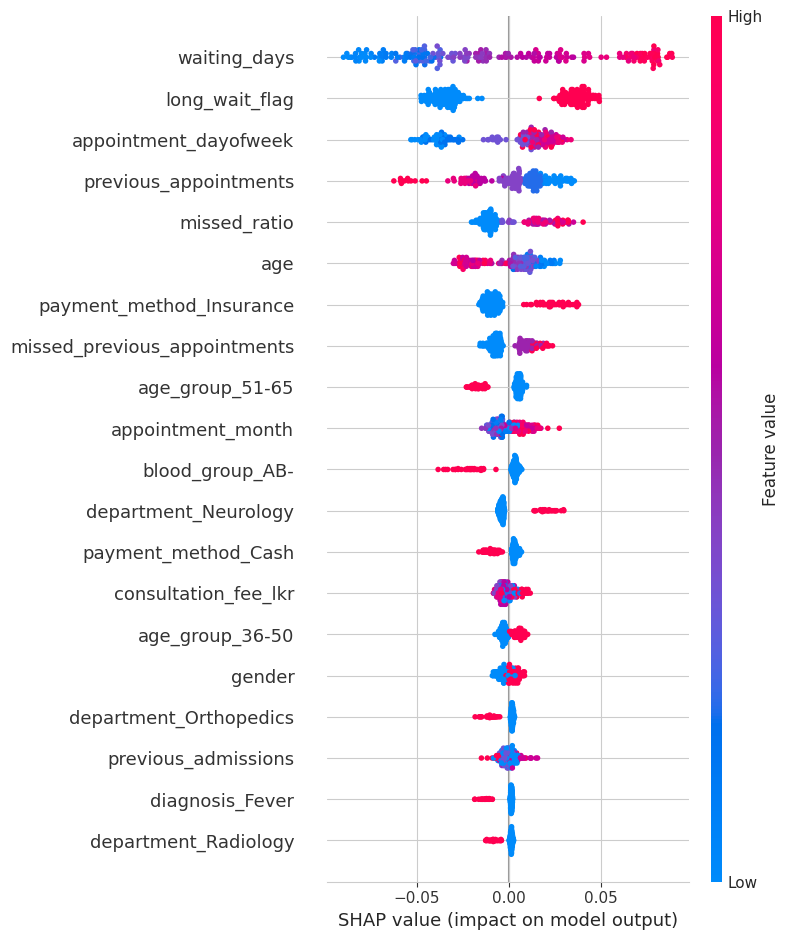

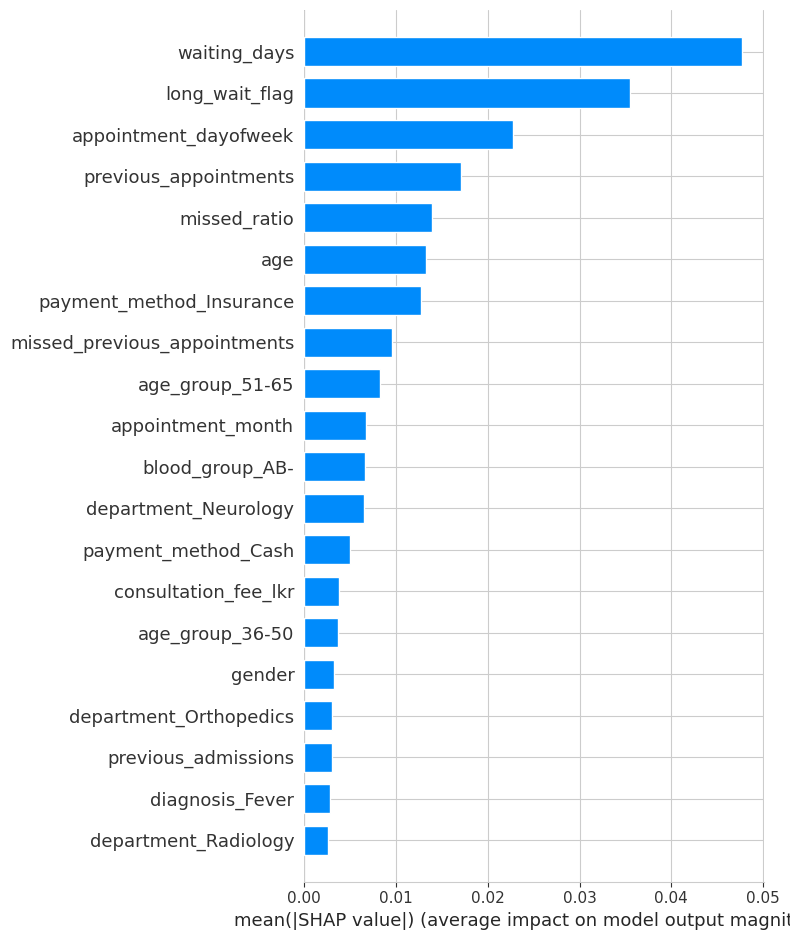

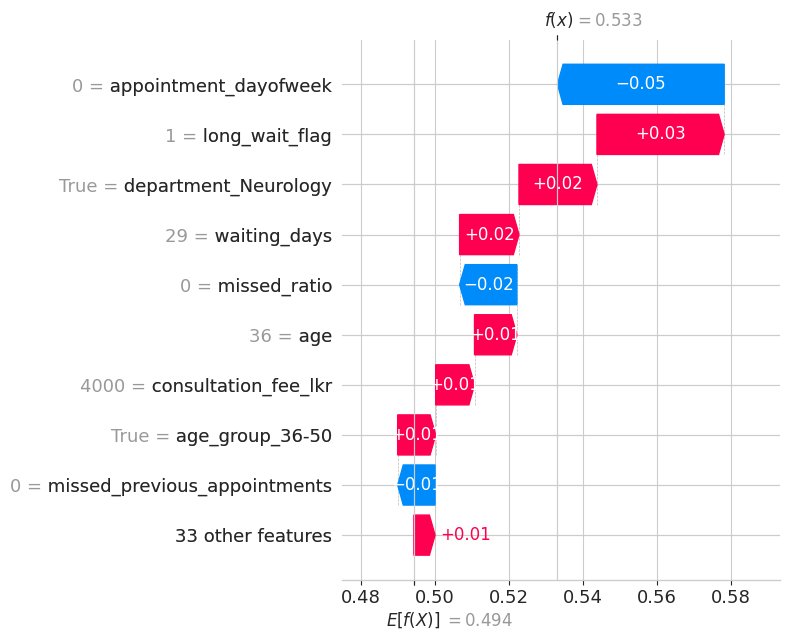


Top 10 Features by SHAP Importance:
waiting_days                    0.047682
long_wait_flag                  0.035544
appointment_dayofweek           0.022744
previous_appointments           0.017107
missed_ratio                    0.013933
age                             0.013315
payment_method_Insurance        0.012760
missed_previous_appointments    0.009539
age_group_51-65                 0.008304
appointment_month               0.006725
dtype: float64

✅ SHAP Analysis Complete!


In [8]:
# ============================================
# CELL 6: TASK 07 - EXPLAINABLE AI (SHAP)
# ============================================

print("=" * 50)
print("SHAP ANALYSIS - EXPLAINABLE AI")
print("=" * 50)

import shap
import joblib

# Load model and data
model = joblib.load('best_model_random_forest.pkl')
X = pd.read_csv('X_processed.csv')
y = pd.read_csv('y.csv').squeeze()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

# Create explainer
print("Creating SHAP explainer...")
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Handle shap_values format
if isinstance(shap_values, list):
    sv = shap_values[1]
elif shap_values.ndim == 3:
    sv = shap_values[:, :, 1]
else:
    sv = shap_values

# 1. Summary Plot
plt.figure(figsize=(9,7))
shap.summary_plot(sv, X_test, feature_names=X_test.columns.tolist(), show=False)
plt.tight_layout()
plt.savefig('10_shap_summary.png')
plt.show()

# 2. Bar Plot
plt.figure(figsize=(8,6))
shap.summary_plot(sv, X_test, plot_type='bar', feature_names=X_test.columns.tolist(), show=False)
plt.tight_layout()
plt.savefig('11_shap_bar.png')
plt.show()

# 3. Waterfall Plot
idx = 0
plt.figure(figsize=(9,5))
base_val = explainer.expected_value if not isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value[1]
shap.waterfall_plot(
    shap.Explanation(
        values=sv[idx],
        base_values=base_val,
        data=X_test.iloc[idx].values,
        feature_names=X_test.columns.tolist()
    ),
    show=False
)
plt.tight_layout()
plt.savefig('12_shap_waterfall.png')
plt.show()

# Print top features
mean_shap = pd.Series(np.abs(sv).mean(axis=0), index=X_test.columns)
print("\nTop 10 Features by SHAP Importance:")
print(mean_shap.sort_values(ascending=False).head(10))

print("\n✅ SHAP Analysis Complete!")

# Create app.py

In [10]:
# CELL: Create app.py for Colab
with open('app.py', 'w') as f:
    f.write('''import streamlit as st
import pandas as pd
import numpy as np
import joblib
import json
import shap
import matplotlib.pyplot as plt
import os

st.set_page_config(page_title="SmartCare No-Show Predictor", page_icon="🏥", layout="centered")

@st.cache_resource
def load_model():
    # Try multiple possible paths for Colab
    possible_paths = [
        'best_model_random_forest.pkl',
        './best_model_random_forest.pkl',
        '../best_model_random_forest.pkl',
        'models/best_model_random_forest.pkl',
    ]

    model = None
    for path in possible_paths:
        if os.path.exists(path):
            try:
                model = joblib.load(path)
                st.success(f"✅ Model loaded from: {path}")
                break
            except Exception as e:
                st.warning(f"⚠️ Could not load from {path}")

    if model is None:
        st.error("❌ Model file not found!")
        st.info(f"📁 Current directory: {os.getcwd()}")
        st.info(f"📁 Files: {os.listdir('.')}")
        return None, None

    # Load feature info
    feature_columns = None
    if os.path.exists('feature_info.json'):
        with open('feature_info.json', 'r') as f:
            feature_info = json.load(f)
            feature_columns = feature_info.get('columns', [])
        st.success("✅ Feature info loaded")

    if feature_columns is None:
        if os.path.exists('X_processed.csv'):
            X = pd.read_csv('X_processed.csv')
            feature_columns = X.columns.tolist()
            st.success("✅ Feature columns loaded from X_processed.csv")

    if feature_columns is None:
        st.error("❌ Feature columns not found!")
        return None, None

    return model, feature_columns

model, feature_columns = load_model()

if model is None or feature_columns is None:
    st.error("⚠️ Could not load model. Please upload required files.")
    st.stop()

st.title("🏥 SmartCare Hospital")
st.subheader("Appointment No-Show Risk Predictor")
st.caption("Predicts probability a patient will miss their appointment")

with st.form("patient_form"):
    st.markdown("### Patient & Appointment Details")

    col1, col2 = st.columns(2)
    with col1:
        age = st.number_input("Age", 1, 100, 35)
        gender = st.selectbox("Gender", ["Male", "Female"])
        blood_group = st.selectbox("Blood Group", ["A+", "A-", "B+", "B-", "AB+", "AB-", "O+", "O-"])
        department = st.selectbox("Department",
            ["General Medicine", "Cardiology", "Neurology", "Orthopedics",
             "Pediatrics", "Radiology", "Laboratory Services"])
        diagnosis = st.selectbox("Diagnosis",
            ["Migraine", "Diabetes", "Back Pain", "Asthma", "Hypertension",
             "Fracture", "Kidney Infection", "Fever", "Chest Pain", "Pneumonia"])

    with col2:
        waiting_days = st.slider("Waiting Days", 0, 60, 20)
        previous_appointments = st.number_input("Previous Appointments", 0, 20, 3)
        missed_prev = st.number_input("Missed Previous", 0, 10, 0)
        previous_admissions = st.number_input("Previous Admissions", 0, 10, 0)
        payment_method = st.selectbox("Payment Method", ["Cash", "Card", "Online", "Insurance"])
        consultation_fee = st.number_input("Consultation Fee (LKR)", 1500, 4000, 2000)

    submitted = st.form_submit_button("🔮 Predict No-Show Risk")

if submitted:
    # Build feature vector
    row = {c: 0 for c in feature_columns}
    row.update({
        "age": age,
        "gender": 1 if gender == "Male" else 0,
        "waiting_days": waiting_days,
        "previous_appointments": previous_appointments,
        "missed_previous_appointments": missed_prev,
        "previous_admissions": previous_admissions,
        "consultation_fee_lkr": consultation_fee,
        "appointment_month": 6,
        "appointment_dayofweek": 3,
        "is_weekend_appt": 0,
        "missed_ratio": missed_prev / (previous_appointments + 1) if previous_appointments > 0 else 0,
        "is_first_visit": int(previous_appointments == 0),
        "long_wait_flag": int(waiting_days > 22)
    })

    # One-hot encoding
    for prefix, val in [("blood_group_", blood_group), ("department_", department),
                        ("diagnosis_", diagnosis), ("payment_method_", payment_method)]:
        key = f"{prefix}{val}"
        if key in row:
            row[key] = 1

    # Age group
    if age <= 18: ag = "0-18"
    elif age <= 35: ag = "19-35"
    elif age <= 50: ag = "36-50"
    elif age <= 65: ag = "51-65"
    else: ag = "65+"
    key = f"age_group_{ag}"
    if key in row:
        row[key] = 1

    X_input = pd.DataFrame([row])[feature_columns]

    # Predict
    proba = model.predict_proba(X_input)[0, 1]
    pred = int(proba >= 0.5)

    st.markdown("---")
    st.markdown("### Prediction Result")

    if pred == 1:
        st.error(f"⚠️ HIGH RISK - No-Show Probability: {proba*100:.1f}%")
    else:
        st.success(f"✅ Likely to Attend - No-Show Probability: {proba*100:.1f}%")

    st.progress(proba)

    # SHAP explanation - FIXED VERSION
    st.markdown("#### Why this prediction?")
    try:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_input)

        if isinstance(shap_values, list):
            sv = shap_values[1][0]
        elif hasattr(shap_values, 'shape') and len(shap_values.shape) == 3:
            sv = shap_values[0, :, 1] if shap_values.shape[2] > 1 else shap_values[0, :, 0]
        elif hasattr(shap_values, 'shape') and len(shap_values.shape) == 2:
            sv = shap_values[0]
        else:
            sv = shap_values

        if isinstance(sv, np.ndarray) and sv.ndim > 1:
            if sv.shape[0] == 1:
                sv = sv.flatten()
            else:
                sv = sv[:, 1] if sv.shape[1] > 1 else sv[:, 0]

        contrib = pd.Series(sv, index=feature_columns)
        contrib = contrib.sort_values(key=abs, ascending=False).head(5)

        fig, ax = plt.subplots(figsize=(7, 4))
        colors = ['#DD4C4C' if v > 0 else '#4C72B0' for v in contrib.values]
        ax.barh(contrib.index[::-1], contrib.values[::-1], color=colors[::-1])
        ax.set_xlabel("SHAP value (impact on no-show risk)")
        ax.set_title("Top factors for this patient")
        st.pyplot(fig)
        st.caption("🔴 Red bars increase no-show risk | 🔵 Blue bars decrease it")

    except Exception as e:
        st.info(f"ℹ️ SHAP explanation: {str(e)[:100]}")
        # Fallback: Show feature importance
        if hasattr(model, 'feature_importances_'):
            st.markdown("**Top features (model importance):**")
            importance = pd.Series(model.feature_importances_, index=feature_columns)
            top_features = importance.sort_values(ascending=False).head(5)
            for feat, imp in top_features.items():
                st.write(f"- {feat}: {imp:.3f}")

st.markdown("---")
st.caption("SmartCare Hospital AI System | CCS3440 Coursework Prototype")
''')

print("✅ app.py created!")

# Download app.py
from google.colab import files
files.download('app.py')
print("✅ app.py downloaded!")

✅ app.py created!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ app.py downloaded!


In [11]:
# CELL: Download all files for local use
from google.colab import files
import os
import json
import joblib
import pandas as pd

# List of files to download
files_to_download = [
    'app.py',
    'best_model_random_forest.pkl',
    'feature_info.json',
    'X_processed.csv'
]

# Check if files exist and download them
for f in files_to_download:
    if os.path.exists(f):
        files.download(f)
        print(f"✅ Downloaded: {f}")
    else:
        print(f"⚠️ File not found: {f}")

print("\n" + "="*60)
print("📌 ALL FILES DOWNLOADED!")
print("="*60)
print("\n📁 Place these files in a folder on your computer:")
print("   - app.py")
print("   - best_model_random_forest.pkl")
print("   - feature_info.json")
print("   - X_processed.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: app.py


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ Downloaded: feature_info.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: X_processed.csv

📌 ALL FILES DOWNLOADED!

📁 Place these files in a folder on your computer:
   - app.py
   - best_model_random_forest.pkl
   - feature_info.json
   - X_processed.csv
